
===== DLC REACH TRAJECTORY (first in-trial reaches) =====
DLC frames: 120268
Canonical time range: 57.14 - 2290.16 s
Bodypart: paw
Frames above likelihood threshold (0.5): 117440 / 120268 (97.6%)
First-in-trial reaches: 48
Kept trials: 48 / 48


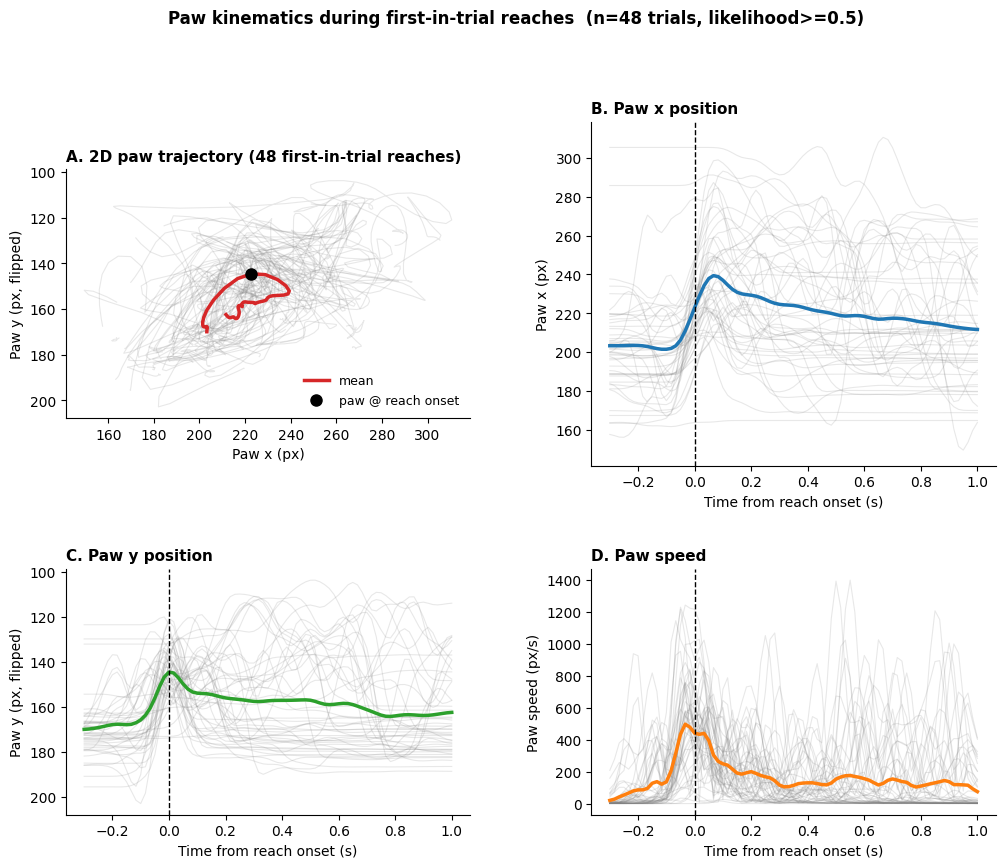


Saved -> DLC_first_reach_trajectories.png / .pdf

===== DONE =====



In [1]:
# ============================================================
# DLC REACH TRAJECTORY — FIRST IN-TRIAL REACHES (03/04)
# ============================================================
# Loads DLC paw kinematics, aligns to first-in-trial reach onsets,
# and plots:
#   A) 2D (x, y) paw trajectory spaghetti
#   B) x position vs time
#   C) y position vs time
#   D) paw speed vs time
# Uses canonical_time for drop-robust frame->second alignment.
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from pathlib import Path
from scipy.ndimage import gaussian_filter1d

print("\n===== DLC REACH TRAJECTORY (first in-trial reaches) =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
analysis_folder = Path(
    r"G:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis"
)
dlc_npz_path = Path(
    r"G:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis\dlc_alignment\full_session_dlc.npz"   # update to the actual path on G drive
)

PRIMARY_BODYPART  = "paw"
LIKELIHOOD_THRESH = 0.5
WIN_PRE_S         = 0.3       # seconds before reach onset
WIN_POST_S        = 1.0       # seconds after reach onset
SMOOTH_SIGMA      = 1.5       # gaussian smoothing on position (in frames; ~25 ms at 60 Hz)
FRAME_RATE        = 60.0
# ------------------------------------------------------------

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------
dlc = np.load(dlc_npz_path, allow_pickle=True)
ct = dlc["canonical_time"]            # (n_frames,)  seconds
px = dlc[f"{PRIMARY_BODYPART}_x"].astype(np.float64)
py = dlc[f"{PRIMARY_BODYPART}_y"].astype(np.float64)
pl = dlc[f"{PRIMARY_BODYPART}_likelihood"]

n_frames = len(ct)
print(f"DLC frames: {n_frames}")
print(f"Canonical time range: {ct[0]:.2f} - {ct[-1]:.2f} s")
print(f"Bodypart: {PRIMARY_BODYPART}")
print(f"Frames above likelihood threshold ({LIKELIHOOD_THRESH}): "
      f"{(pl >= LIKELIHOOD_THRESH).sum()} / {n_frames} "
      f"({100*(pl >= LIKELIHOOD_THRESH).mean():.1f}%)")

# Mask low-likelihood frames with NaN BEFORE smoothing
px_masked = np.where(pl >= LIKELIHOOD_THRESH, px, np.nan)
py_masked = np.where(pl >= LIKELIHOOD_THRESH, py, np.nan)

# Smooth (mild) — using gaussian_filter1d with nan-preserving via fill+filter trick
# Actually we'll smooth per-trial below to avoid contaminating across reach boundaries.

# ------------------------------------------------------------
# LOAD REACH EVENTS (first in-trial reaches)
# ------------------------------------------------------------
bouts = np.load(analysis_folder / "peak_detection" / "bouts.npz")
onset_t = bouts["onset_t"]
trial_id = bouts["trial_id"]

first_idx = []
for tid in sorted(set(trial_id[trial_id >= 0])):
    ii = np.where(trial_id == tid)[0]
    first_idx.append(ii[np.argmin(onset_t[ii])])
first_reach_t = np.sort(onset_t[np.array(first_idx)])
print(f"First-in-trial reaches: {len(first_reach_t)}")

# ------------------------------------------------------------
# EXTRACT PER-TRIAL TRAJECTORIES (aligned via canonical_time)
# ------------------------------------------------------------
# Build a regular time axis at 60 Hz spanning the window
window_dt = 1.0 / FRAME_RATE
window_times = np.arange(-WIN_PRE_S, WIN_POST_S + window_dt/2, window_dt)
n_bins = len(window_times)

trial_x = np.full((len(first_reach_t), n_bins), np.nan)
trial_y = np.full((len(first_reach_t), n_bins), np.nan)

kept_trials = 0
for ti, t_reach in enumerate(first_reach_t):
    # Find DLC frame closest to reach onset
    onset_frame = np.searchsorted(ct, t_reach)
    # Find window bounds
    t_lo = t_reach - WIN_PRE_S
    t_hi = t_reach + WIN_POST_S
    f_lo = np.searchsorted(ct, t_lo)
    f_hi = np.searchsorted(ct, t_hi)
    if f_hi - f_lo < 5:
        continue  # skip trials with too few frames (dropped chunk?)

    # Resample to regular grid using nearest-frame lookup
    target_times = t_reach + window_times
    target_frames = np.searchsorted(ct, target_times)
    target_frames = np.clip(target_frames, 0, n_frames - 1)
    # If any target time is more than 2 frame periods off from its assigned frame, mark NaN
    actual_times = ct[target_frames]
    bad = np.abs(actual_times - target_times) > 2 * window_dt
    tx = px_masked[target_frames].copy()
    ty = py_masked[target_frames].copy()
    tx[bad] = np.nan; ty[bad] = np.nan

    # Light smoothing per-trial (skip if too few valid frames)
    n_valid = np.sum(~np.isnan(tx))
    if n_valid >= 5:
        # Use a simple fill-then-smooth pattern for nans
        for arr in (tx, ty):
            mask = ~np.isnan(arr)
            if mask.sum() >= 3:
                idx = np.where(mask)[0]
                arr[~mask] = np.interp(np.where(~mask)[0], idx, arr[mask])
        tx = gaussian_filter1d(tx, sigma=SMOOTH_SIGMA)
        ty = gaussian_filter1d(ty, sigma=SMOOTH_SIGMA)

    trial_x[ti] = tx
    trial_y[ti] = ty
    kept_trials += 1

print(f"Kept trials: {kept_trials} / {len(first_reach_t)}")

# Compute speed: |d/dt of position|, smoothed
trial_speed = np.full_like(trial_x, np.nan)
for ti in range(len(first_reach_t)):
    dx = np.gradient(trial_x[ti]) * FRAME_RATE
    dy = np.gradient(trial_y[ti]) * FRAME_RATE
    trial_speed[ti] = np.sqrt(dx**2 + dy**2)

# Means (ignoring NaN)
mean_x = np.nanmean(trial_x, axis=0)
mean_y = np.nanmean(trial_y, axis=0)
mean_speed = np.nanmean(trial_speed, axis=0)

# Identify the time-zero index for plotting paw-at-onset
t_zero_idx = np.argmin(np.abs(window_times))

# ------------------------------------------------------------
# FIGURE
# ------------------------------------------------------------
fig = plt.figure(figsize=(12, 9))
gs = GridSpec(2, 2, height_ratios=[1.4, 1.0], width_ratios=[1, 1],
              hspace=0.35, wspace=0.30)

# ---- Panel A: 2D trajectory ----
ax = fig.add_subplot(gs[0, 0])
for ti in range(len(first_reach_t)):
    ax.plot(trial_x[ti], trial_y[ti], "-", color="0.5", alpha=0.18, lw=0.8)
# Mean
ax.plot(mean_x, mean_y, "-", color="C3", lw=2.5, label="mean")
# Paw position at reach onset
ax.plot(mean_x[t_zero_idx], mean_y[t_zero_idx], "o",
        color="black", markersize=8, label="paw @ reach onset", zorder=5)
ax.invert_yaxis()  # image coord -> natural display
ax.set_xlabel("Paw x (px)")
ax.set_ylabel("Paw y (px, flipped)")
ax.set_aspect("equal")
ax.set_title(f"A. 2D paw trajectory ({kept_trials} first-in-trial reaches)",
             fontsize=11, fontweight="bold", loc="left")
ax.legend(fontsize=9, loc="best", frameon=False)
ax.spines[["top", "right"]].set_visible(False)

# ---- Panel B: x vs time ----
ax = fig.add_subplot(gs[0, 1])
for ti in range(len(first_reach_t)):
    ax.plot(window_times, trial_x[ti], "-", color="0.5", alpha=0.18, lw=0.8)
ax.plot(window_times, mean_x, "-", color="C0", lw=2.5, label="mean")
ax.axvline(0, color="black", lw=1, linestyle="--")
ax.set_xlabel("Time from reach onset (s)")
ax.set_ylabel("Paw x (px)")
ax.set_title("B. Paw x position", fontsize=11, fontweight="bold", loc="left")
ax.spines[["top", "right"]].set_visible(False)

# ---- Panel C: y vs time ----
ax = fig.add_subplot(gs[1, 0])
for ti in range(len(first_reach_t)):
    ax.plot(window_times, trial_y[ti], "-", color="0.5", alpha=0.18, lw=0.8)
ax.plot(window_times, mean_y, "-", color="C2", lw=2.5, label="mean")
ax.axvline(0, color="black", lw=1, linestyle="--")
ax.invert_yaxis()
ax.set_xlabel("Time from reach onset (s)")
ax.set_ylabel("Paw y (px, flipped)")
ax.set_title("C. Paw y position", fontsize=11, fontweight="bold", loc="left")
ax.spines[["top", "right"]].set_visible(False)

# ---- Panel D: speed vs time ----
ax = fig.add_subplot(gs[1, 1])
for ti in range(len(first_reach_t)):
    ax.plot(window_times, trial_speed[ti], "-", color="0.5", alpha=0.18, lw=0.8)
ax.plot(window_times, mean_speed, "-", color="C1", lw=2.5, label="mean")
ax.axvline(0, color="black", lw=1, linestyle="--")
ax.set_xlabel("Time from reach onset (s)")
ax.set_ylabel("Paw speed (px/s)")
ax.set_title("D. Paw speed", fontsize=11, fontweight="bold", loc="left")
ax.spines[["top", "right"]].set_visible(False)

plt.suptitle(f"Paw kinematics during first-in-trial reaches  "
             f"(n={kept_trials} trials, likelihood>={LIKELIHOOD_THRESH})",
             fontsize=12, fontweight="bold", y=1.005)

out_base = analysis_folder / "qc" / "DLC_first_reach_trajectories"
plt.savefig(f"{out_base}.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig(f"{out_base}.pdf", bbox_inches="tight", facecolor="white")
plt.show()
print(f"\nSaved -> {out_base.name}.png / .pdf")
print("\n===== DONE =====\n")


===== DLC REACH TRAJECTORY (variants) =====
DLC frames: 120268, canonical_time: 57.1-2290.2 s
Frames above likelihood 0.5: 117440 / 120268 (97.6%)
First-in-trial reaches: 48

Computing onset-aligned trajectories...
  kept: 48/48
Computing peak-aligned trajectories...
  kept: 48/48


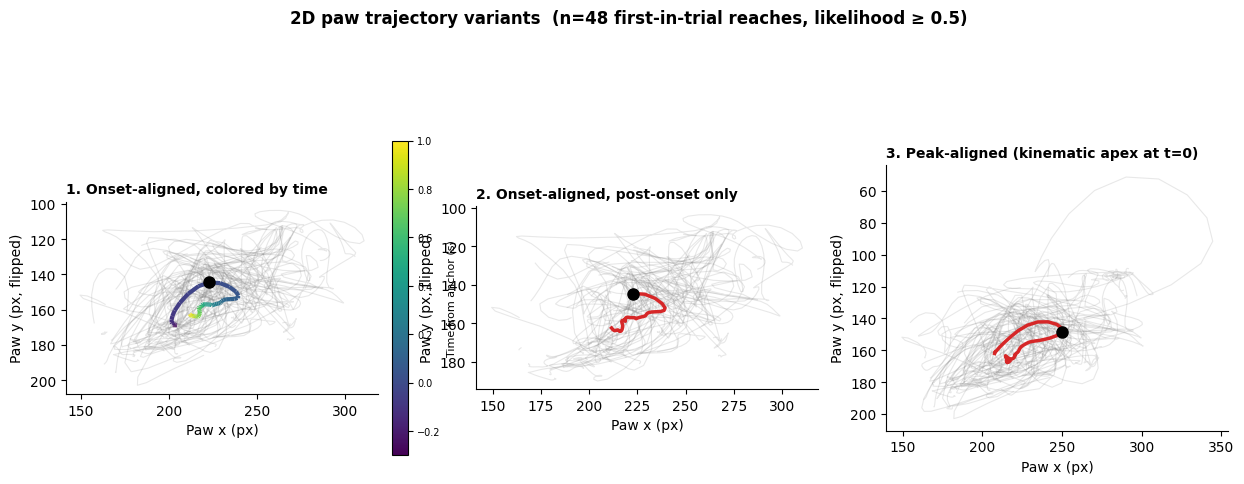


Saved -> DLC_firstreach_trajectory_variants.png / .pdf

===== DONE =====



In [4]:
# ============================================================
# DLC REACH TRAJECTORY — VARIANTS (color, post-only, peak-aligned)
# ============================================================
# Toggles:
#   - FIRST_REACH_ONLY:  True = first reach per trial; False = all in-trial reaches
#   - VARIANT:           "color_by_time" | "post_only" | "peak_aligned" | "compare"
#
# Three alignment/visualization variants for the 2D trajectory:
#   1) "color_by_time"  — onset-aligned, mean line colored by time
#   2) "post_only"      — onset-aligned, only post-onset segment shown
#   3) "peak_aligned"   — re-aligned to peak time (kinematic apex)
# Set VARIANT = "compare" to render all three side by side.
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
from matplotlib.gridspec import GridSpec
from pathlib import Path
from scipy.ndimage import gaussian_filter1d

print("\n===== DLC REACH TRAJECTORY (variants) =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
analysis_folder = Path(
    r"G:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis"
)
dlc_npz_path = Path(
    r"G:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis\dlc_alignment\full_session_dlc.npz"
)

FIRST_REACH_ONLY = True       # True: first reach per trial only; False: all in-trial reaches
VARIANT = "compare"           # "color_by_time" | "post_only" | "peak_aligned" | "compare"

PRIMARY_BODYPART  = "paw"
LIKELIHOOD_THRESH = 0.5
WIN_PRE_S         = 0.3
WIN_POST_S        = 1.0
SMOOTH_SIGMA      = 1.5
FRAME_RATE        = 60.0
# ------------------------------------------------------------

# ------------------------------------------------------------
# LOAD DLC
# ------------------------------------------------------------
dlc = np.load(dlc_npz_path, allow_pickle=True)
ct = dlc["canonical_time"]
px = dlc[f"{PRIMARY_BODYPART}_x"].astype(np.float64)
py = dlc[f"{PRIMARY_BODYPART}_y"].astype(np.float64)
pl = dlc[f"{PRIMARY_BODYPART}_likelihood"]
n_frames = len(ct)
print(f"DLC frames: {n_frames}, canonical_time: {ct[0]:.1f}-{ct[-1]:.1f} s")
print(f"Frames above likelihood {LIKELIHOOD_THRESH}: "
      f"{(pl >= LIKELIHOOD_THRESH).sum()} / {n_frames} "
      f"({100*(pl >= LIKELIHOOD_THRESH).mean():.1f}%)")

px_masked = np.where(pl >= LIKELIHOOD_THRESH, px, np.nan)
py_masked = np.where(pl >= LIKELIHOOD_THRESH, py, np.nan)

# ------------------------------------------------------------
# LOAD REACH EVENTS — filter by toggle
# ------------------------------------------------------------
bouts = np.load(analysis_folder / "peak_detection" / "bouts.npz")
onset_t_all = bouts["onset_t"]
peak_t_all  = bouts["peak_t"]
trial_id    = bouts["trial_id"]

if FIRST_REACH_ONLY:
    keep_idx = []
    for tid in sorted(set(trial_id[trial_id >= 0])):
        ii = np.where(trial_id == tid)[0]
        keep_idx.append(ii[np.argmin(onset_t_all[ii])])
    keep_idx = np.array(keep_idx)
    subset_label = "first-in-trial"
else:
    keep_idx = np.where(trial_id >= 0)[0]
    subset_label = "all in-trial"

order = np.argsort(onset_t_all[keep_idx])
keep_idx = keep_idx[order]

reach_onset_t = onset_t_all[keep_idx]
reach_peak_t  = peak_t_all[keep_idx]
print(f"{subset_label.capitalize()} reaches: {len(reach_onset_t)}")

# ------------------------------------------------------------
# EXTRACT PER-TRIAL TRAJECTORIES (helper)
# ------------------------------------------------------------
def extract_trajectories(anchor_times, win_pre, win_post):
    window_dt = 1.0 / FRAME_RATE
    window_times = np.arange(-win_pre, win_post + window_dt/2, window_dt)
    n_bins = len(window_times)
    n_trials = len(anchor_times)

    trial_x = np.full((n_trials, n_bins), np.nan)
    trial_y = np.full((n_trials, n_bins), np.nan)
    kept = 0

    for ti, t_anchor in enumerate(anchor_times):
        target_times = t_anchor + window_times
        target_frames = np.searchsorted(ct, target_times)
        target_frames = np.clip(target_frames, 0, n_frames - 1)
        actual_times = ct[target_frames]
        bad = np.abs(actual_times - target_times) > 2 * window_dt

        tx = px_masked[target_frames].copy()
        ty = py_masked[target_frames].copy()
        tx[bad] = np.nan; ty[bad] = np.nan

        n_valid = np.sum(~np.isnan(tx))
        if n_valid >= 5:
            for arr in (tx, ty):
                mask = ~np.isnan(arr)
                if mask.sum() >= 3:
                    idx = np.where(mask)[0]
                    arr[~mask] = np.interp(np.where(~mask)[0], idx, arr[mask])
            tx = gaussian_filter1d(tx, sigma=SMOOTH_SIGMA)
            ty = gaussian_filter1d(ty, sigma=SMOOTH_SIGMA)
            kept += 1
        trial_x[ti] = tx
        trial_y[ti] = ty

    trial_speed = np.full_like(trial_x, np.nan)
    for ti in range(n_trials):
        dx = np.gradient(trial_x[ti]) * FRAME_RATE
        dy = np.gradient(trial_y[ti]) * FRAME_RATE
        trial_speed[ti] = np.sqrt(dx**2 + dy**2)

    return trial_x, trial_y, trial_speed, window_times, kept

# ------------------------------------------------------------
# COMPUTE BOTH ALIGNMENT VARIANTS
# ------------------------------------------------------------
print("\nComputing onset-aligned trajectories...")
tx_on, ty_on, ts_on, wt_on, kept_on = extract_trajectories(
    reach_onset_t, WIN_PRE_S, WIN_POST_S)
print(f"  kept: {kept_on}/{len(reach_onset_t)}")

print("Computing peak-aligned trajectories...")
tx_pk, ty_pk, ts_pk, wt_pk, kept_pk = extract_trajectories(
    reach_peak_t, WIN_PRE_S, WIN_POST_S)
print(f"  kept: {kept_pk}/{len(reach_peak_t)}")

mean_x_on = np.nanmean(tx_on, axis=0)
mean_y_on = np.nanmean(ty_on, axis=0)
mean_x_pk = np.nanmean(tx_pk, axis=0)
mean_y_pk = np.nanmean(ty_pk, axis=0)

t_zero_on = np.argmin(np.abs(wt_on))
t_zero_pk = np.argmin(np.abs(wt_pk))

# ------------------------------------------------------------
# HELPER: draw a 2D trajectory panel
# ------------------------------------------------------------
def draw_2d_panel(ax, variant, trial_x, trial_y, mean_x, mean_y,
                  window_times, t_zero_idx, kept_n, title):
    if variant == "post_only":
        keep = slice(t_zero_idx, None)
        tx = trial_x[:, keep]; ty = trial_y[:, keep]
        mx = mean_x[keep]; my = mean_y[keep]
        wt = window_times[keep]
    else:
        tx, ty = trial_x, trial_y
        mx, my = mean_x, mean_y
        wt = window_times

    for ti in range(tx.shape[0]):
        ax.plot(tx[ti], ty[ti], "-", color="0.5", alpha=0.18, lw=0.8)

    if variant == "color_by_time":
        pts = np.column_stack([mx, my])
        valid = ~(np.isnan(pts[:, 0]) | np.isnan(pts[:, 1]))
        pts_v = pts[valid]; wt_v = wt[valid]
        if len(pts_v) >= 2:
            segments = np.stack([pts_v[:-1], pts_v[1:]], axis=1)
            cmap = plt.cm.viridis
            norm = mcolors.Normalize(vmin=wt_v[0], vmax=wt_v[-1])
            lc = LineCollection(segments, cmap=cmap, norm=norm,
                                linewidth=3.0, zorder=4)
            lc.set_array(wt_v[:-1])
            ax.add_collection(lc)
            cb = plt.colorbar(lc, ax=ax, fraction=0.046, pad=0.04)
            cb.set_label("Time from anchor (s)", fontsize=8)
            cb.ax.tick_params(labelsize=7)
    else:
        ax.plot(mx, my, "-", color="C3", lw=2.5, zorder=4)

    if variant == "post_only":
        if not (np.isnan(mx[0]) or np.isnan(my[0])):
            ax.plot(mx[0], my[0], "o", color="black", markersize=8, zorder=5)
    else:
        if not (np.isnan(mean_x[t_zero_idx]) or np.isnan(mean_y[t_zero_idx])):
            ax.plot(mean_x[t_zero_idx], mean_y[t_zero_idx], "o",
                    color="black", markersize=8, zorder=5)

    ax.invert_yaxis()
    ax.set_xlabel("Paw x (px)")
    ax.set_ylabel("Paw y (px, flipped)")
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=10, fontweight="bold", loc="left")
    ax.spines[["top", "right"]].set_visible(False)

# ------------------------------------------------------------
# FIGURE — branches on VARIANT
# ------------------------------------------------------------
if VARIANT == "compare":
    fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
    draw_2d_panel(axes[0], "color_by_time",
                  tx_on, ty_on, mean_x_on, mean_y_on, wt_on, t_zero_on,
                  kept_on, "1. Onset-aligned, colored by time")
    draw_2d_panel(axes[1], "post_only",
                  tx_on, ty_on, mean_x_on, mean_y_on, wt_on, t_zero_on,
                  kept_on, "2. Onset-aligned, post-onset only")
    draw_2d_panel(axes[2], "peak_aligned",
                  tx_pk, ty_pk, mean_x_pk, mean_y_pk, wt_pk, t_zero_pk,
                  kept_pk, "3. Peak-aligned (kinematic apex at t=0)")

    plt.suptitle(f"2D paw trajectory variants  "
                 f"(n={kept_on} {subset_label} reaches, "
                 f"likelihood ≥ {LIKELIHOOD_THRESH})",
                 fontsize=12, fontweight="bold", y=1.02)
    fn_subset = "firstreach" if FIRST_REACH_ONLY else "allreaches"
    out_name = f"DLC_{fn_subset}_trajectory_variants"

else:
    fig = plt.figure(figsize=(12, 9))
    gs = GridSpec(2, 2, height_ratios=[1.4, 1.0], width_ratios=[1, 1],
                  hspace=0.35, wspace=0.30)

    if VARIANT == "peak_aligned":
        tx, ty, ts, wt, tz, kept_n = tx_pk, ty_pk, ts_pk, wt_pk, t_zero_pk, kept_pk
        mx, my = mean_x_pk, mean_y_pk
        anchor_label = "peak"
    else:
        tx, ty, ts, wt, tz, kept_n = tx_on, ty_on, ts_on, wt_on, t_zero_on, kept_on
        mx, my = mean_x_on, mean_y_on
        anchor_label = "onset"
    mean_speed = np.nanmean(ts, axis=0)

    ax = fig.add_subplot(gs[0, 0])
    panel_title = {
        "color_by_time": f"A. 2D trajectory, colored by time (t=0 at {anchor_label})",
        "post_only":     f"A. 2D trajectory, post-{anchor_label} only",
        "peak_aligned":  f"A. 2D trajectory, peak-aligned"
    }[VARIANT]
    draw_2d_panel(ax, VARIANT, tx, ty, mx, my, wt, tz, kept_n, panel_title)

    ax = fig.add_subplot(gs[0, 1])
    for ti in range(tx.shape[0]):
        ax.plot(wt, tx[ti], "-", color="0.5", alpha=0.18, lw=0.8)
    ax.plot(wt, mx, "-", color="C0", lw=2.5)
    ax.axvline(0, color="black", lw=1, linestyle="--")
    ax.set_xlabel(f"Time from {anchor_label} (s)")
    ax.set_ylabel("Paw x (px)")
    ax.set_title(f"B. Paw x position", fontsize=11, fontweight="bold", loc="left")
    ax.spines[["top", "right"]].set_visible(False)

    ax = fig.add_subplot(gs[1, 0])
    for ti in range(ty.shape[0]):
        ax.plot(wt, ty[ti], "-", color="0.5", alpha=0.18, lw=0.8)
    ax.plot(wt, my, "-", color="C2", lw=2.5)
    ax.axvline(0, color="black", lw=1, linestyle="--")
    ax.invert_yaxis()
    ax.set_xlabel(f"Time from {anchor_label} (s)")
    ax.set_ylabel("Paw y (px, flipped)")
    ax.set_title(f"C. Paw y position", fontsize=11, fontweight="bold", loc="left")
    ax.spines[["top", "right"]].set_visible(False)

    ax = fig.add_subplot(gs[1, 1])
    for ti in range(ts.shape[0]):
        ax.plot(wt, ts[ti], "-", color="0.5", alpha=0.18, lw=0.8)
    ax.plot(wt, mean_speed, "-", color="C1", lw=2.5)
    ax.axvline(0, color="black", lw=1, linestyle="--")
    ax.set_xlabel(f"Time from {anchor_label} (s)")
    ax.set_ylabel("Paw speed (px/s)")
    ax.set_title(f"D. Paw speed", fontsize=11, fontweight="bold", loc="left")
    ax.spines[["top", "right"]].set_visible(False)

    plt.suptitle(f"Paw kinematics during {subset_label} reaches  "
                 f"(n={kept_n}, variant={VARIANT}, "
                 f"likelihood ≥ {LIKELIHOOD_THRESH})",
                 fontsize=12, fontweight="bold", y=1.005)
    fn_subset = "firstreach" if FIRST_REACH_ONLY else "allreaches"
    out_name = f"DLC_{fn_subset}_trajectories_{VARIANT}"

out_base = analysis_folder / "qc" / out_name
plt.savefig(f"{out_base}.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig(f"{out_base}.pdf", bbox_inches="tight", facecolor="white")
plt.show()
print(f"\nSaved -> {out_base.name}.png / .pdf")
print("\n===== DONE =====\n")